In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.trainer import OneDimensionalTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import Put
from binomial_tree.binomial_tree import binomial_tree

In [2]:
S0 = 1.0
r = 0.1
sigma = 0.4
K = 2.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put = Put()
trainer = OneDimensionalTrainer(model_config, market_params, put, 67)
trainer.train(num_samples=1000, max_iterations=10000, tol=1e-6)

Iteration 0, Loss: 8.438322067260742
Iteration 100, Loss: 0.11359059065580368
Iteration 200, Loss: 0.007403576746582985
Iteration 300, Loss: 0.0021187118254601955
Converged at iteration 326


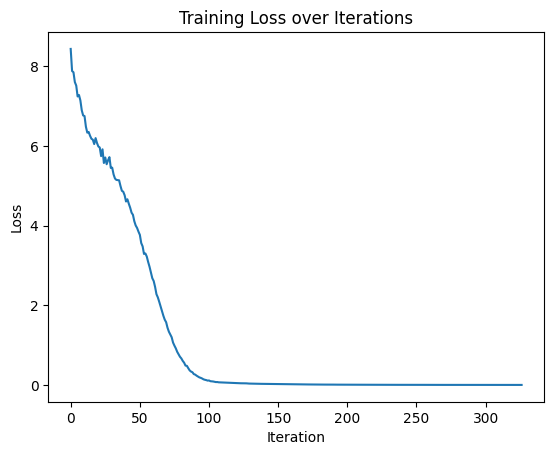

In [5]:
trainer.plot_losses()

In [6]:
trainer.predict(0, 1).item()

1.0890506505966187

In [7]:
bt_price, _, _ = binomial_tree(S=S0, K=K, T=T, r=r, sigma=sigma, n=1000)
print(bt_price)

1.0


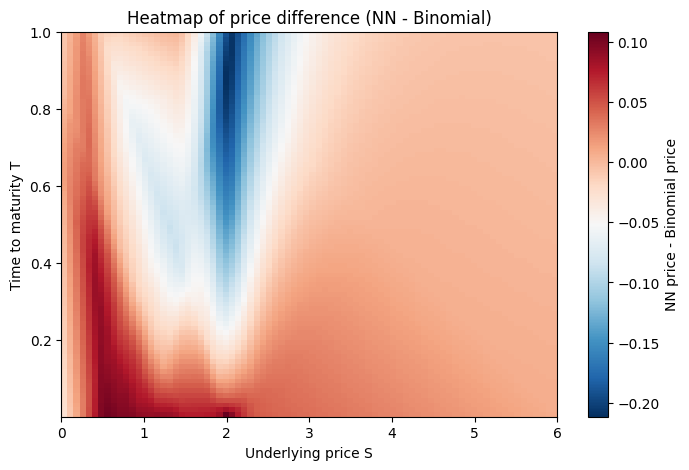

In [8]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(1e-6, T, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_price, _, _ = binomial_tree(S=s_val, K=K, T=t_val, r=r, sigma=sigma, n=200)
        bt_prices[i, j] = float(bt_price)

diff = nn_prices - bt_prices

plt.figure(figsize=(8, 5))
im = plt.imshow(diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='NN price - Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time to maturity T')
plt.title('Heatmap of price difference (NN - Binomial)')
plt.show()

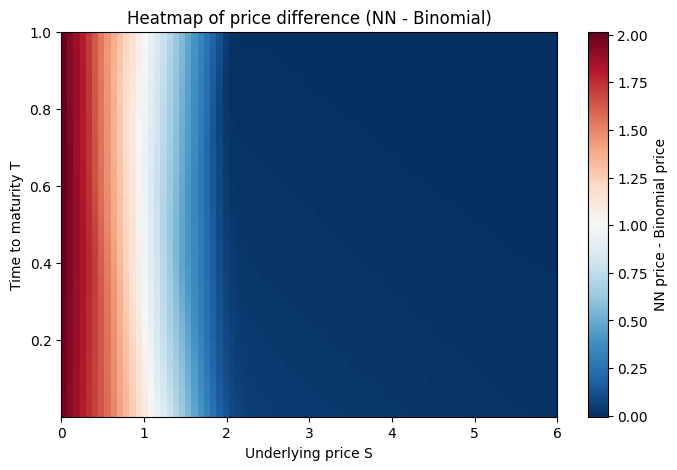

In [9]:
plt.figure(figsize=(8, 5))
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='NN price - Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time to maturity T')
plt.title('Heatmap of price difference (NN - Binomial)')
plt.show()

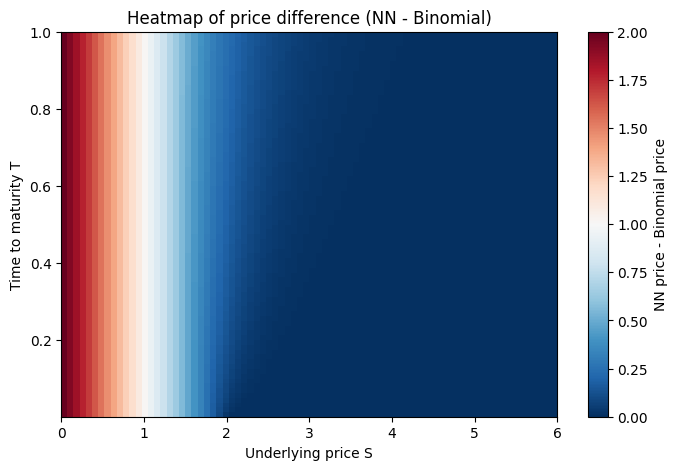

In [10]:
plt.figure(figsize=(8, 5))
im = plt.imshow(bt_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='NN price - Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time to maturity T')
plt.title('Heatmap of price difference (NN - Binomial)')
plt.show()